In [30]:
from escripts import eMCMC
from escripts import edata
import importlib
from escripts import eplots

In [163]:
# Get data
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt',]
data_labels = ['Bouwens+21', 'Donnan+24']
sorted_data = edata.get_sorted(file_names, data_labels)

# Initialize parameters
params = eMCMC.build_param_data({'beta': {'fit':False, 'value': -0.54}, 'dbetadz': {'fit': False, 'value':0}})

# Initialize UVLF object
my_UVLF = eMCMC.UVLF(sorted_data, params, precisionboost = 10)

In [164]:
no_z_ev = [0.82, -0.03, 12.38, 0.16, -0.91, -0.03, 0.89, 0, -0.77]
no_M_ev = [0.6, -0.02, 12.04, 0.09, -0.93, -0.04, 0.23, 0.26, 0]
std = [0.88, 0.06, 11.7, 0, -0.98, -0.05, 0.18, 0.17, -0.89]

In [165]:
# Get the data
idx = 5
z = my_UVLF.data[idx][0]
zerr = my_UVLF.data[idx][1]
# Get the biggest possible grid of x data to plot over
plot_xdat, xdat_inds = np.unique(np.concatenate([data[2] for data in my_UVLF.data]), return_index = True) 
# Get the corresponding x error
plot_xerr = np.concatenate([data[6] for data in my_UVLF.data])[xdat_inds]

In [166]:
no_z_UVLF, no_z_bias = my_UVLF.UVLF_wrapper(z, zerr, plot_xdat, plot_xerr, no_z_ev, get_bias = True)
no_M_UVLF, no_M_bias = my_UVLF.UVLF_wrapper(z, zerr, plot_xdat, plot_xerr, no_M_ev, get_bias = True)
std_UVLF, std_bias = my_UVLF.UVLF_wrapper(z, zerr, plot_xdat, plot_xerr, std, get_bias = True)

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


Text(0.5, 1.0, '$8.5 \\lesssim z \\lesssim 9.5$')

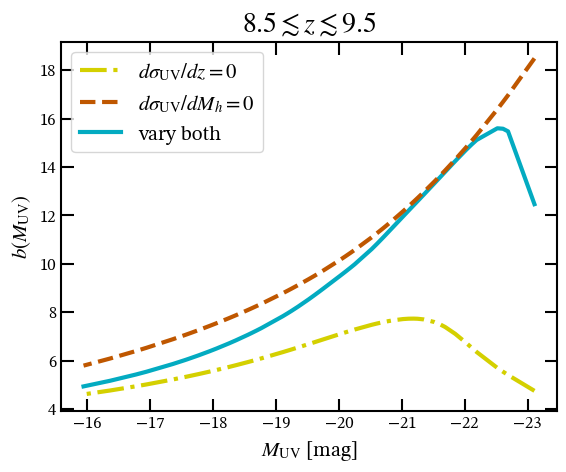

In [167]:
fig, ax = plt.subplots()
ax.plot(plot_xdat, no_z_bias, color = eplots.yellow, label = r'$d\sigma_{\rm{UV}}/dz = 0$', ls = 'dashdot')
ax.plot(plot_xdat, no_M_bias, color = eplots.orange, label = r'$d\sigma_{\rm{UV}}/dM_{h} = 0$', ls = 'dashed')
ax.plot(plot_xdat, std_bias, color = eplots.turquoise, label = r'vary both', ls = '-', zorder = 0)
ax.invert_xaxis()
ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')
ax.set_ylabel(r'$b(M_{\rm{UV}})$')
ax.legend()
ax.set_title(fr'${round(z-zerr, 1)} \lesssim z \lesssim {round(z+zerr, 1)}$', fontsize = 20, pad = 8)

In [168]:
fig.savefig('/Users/eb35267/Desktop/code/home/figures/bias/increase_mass_resolution.png', bbox_inches='tight')

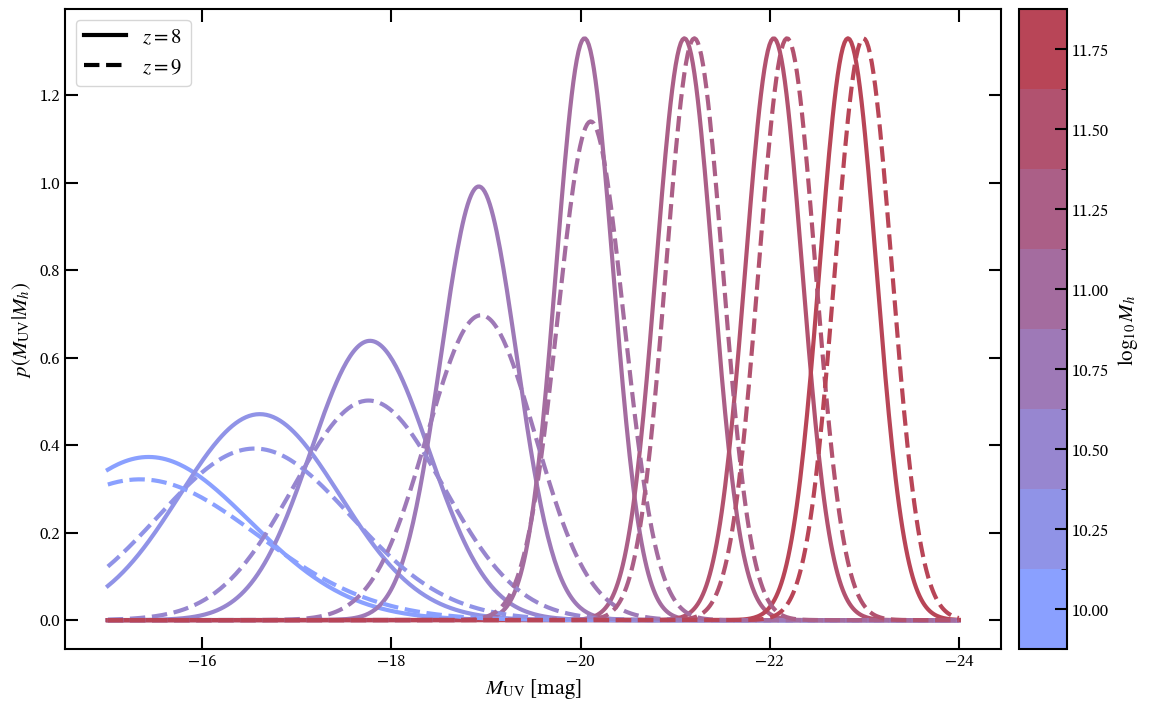

In [133]:
Mhtab = np.arange(10, 12, 0.25)
dist_fig, ax = eplots.MUV_distribution(my_UVLF, zs = [8, 9], param_values = std, Mhtab = Mhtab)

In [127]:
eMCMC.get_default_df()

,fit,value,lower,upper,label
alpha,True,0.6,0,4,$\alpha$
dalphadz,True,0,-0.5,0.5,$d\alpha/dz$
beta,True,-0.5,-3,0,$\beta$
dbetadz,True,0,-1,1.5,$d\beta/dz$
logMc,True,12,9,16,$\log(M_c)$
dlogMcdz,True,0,-0.5,0.5,$d\log(M_c)/dz$
loge,True,-0.5,-4.5,0,$\log(\epsilon_{\star})$
dlogedz,True,0,-0.5,0.5,$d\log(\epsilon_{\star})/dz$
sig,True,0,0,6,"$\sigma_{\rm{UV}, M_c}$"
dsigdz,True,0,-1,1,$d\sigma_{\rm{UV}}/dz$


In [131]:
my_UVLF.Astro_Parameters._zpivot

8.0

In [82]:
dist_fig.savefig('/Users/eb35267/Desktop/code/home/figures/distribution_test.png', bbox_inches = 'tight')

In [52]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

(<Figure size 1200x800 with 2 Axes>,
 <Axes: xlabel='$M_{\\rm{UV}}$ [mag]', ylabel='$p(M_{\\rm{UV}}|M_h)$'>)

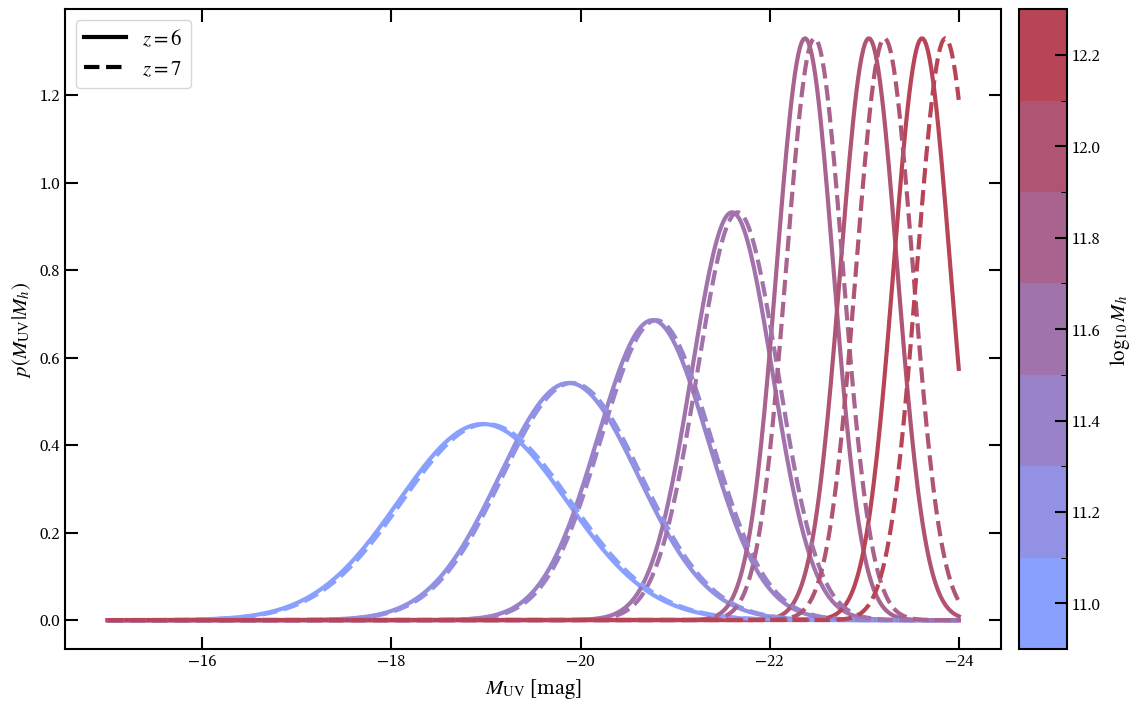

In [68]:
Mhtab = np.arange(11, 12.3, 0.2)
eplots.MUV_distribution(my_UVLF, zs = [6, 7], param_values = no_z_ev, Mhtab = Mhtab)